In [2]:

import os


os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # add this

import jax
import jax.numpy as jnp
from pathlib import Path


import matplotlib.pyplot as plt
# from scipy.optimize import minimize

# import optax

# from jax.example_libraries import optimizers

# import jaxopt

import numpy as np

import os

# from functools import partial


import importlib


# from qiskit_aer import Aer, AerSimulator

import sys

from jax import config as jax_config

import time


def try_set_gpu():
    try:
        # Try to trigger GPU backend
        jax.devices("gpu")[0]
        print("✅ Running on GPU:", jax.devices("gpu")[0])
    except Exception as e:
        print("⚠️ GPU initialization failed, falling back to CPU.")
        print("Error was:", e)

        # Set platform to CPU before any more JAX ops
        jax_config.update("jax_platform_name", "cpu")

        # Reimport jaxlib backend to reflect change (optional)
        # or rerun script with environment variable instead


# Apply before other JAX operations
try_set_gpu()

# parameters1 = {'init_temp': 300.0,
#                'min_temp': 2 / 3,
#                'decay_rate_temp': 2e-05,
#                'init_value': 1.0,
#                'decay_rate': 0.75,
#                'transition_steps': 1550,
#                'alpha': 0.8,
#                'scale': 0.1}







⚠️ GPU initialization failed, falling back to CPU.
Error was: Unknown backend: 'gpu' requested, but no platforms that are instances of gpu are present. Platforms present are: cpu


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Match style used in figures_notebooks/fig4_nps_nq_alpha_ch.ipynb
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / '.git').exists():
    REPO_ROOT = REPO_ROOT.parent
plt.style.use(str(REPO_ROOT / 'figures_notebooks' / 'single_column.mplstyle'))


def _load_distances_for_n(nq):
    candidates = [
        REPO_ROOT / 'paper_data' / 'shadow_surrogate_comparison' / f'distances_{nq}.npy',
        REPO_ROOT / 'surogate' / f'distances_{nq}.npy',
    ]
    for p in candidates:
        if p.exists():
            return np.load(p)
    raise FileNotFoundError(f'Could not find distances_{nq}.npy in known locations.')


def _channel_is_valid(arr, idx):
    # Some channels are unfilled in saved arrays; skip all-zero channels.
    return not np.all(arr[idx] == 0)


def _reconstruct_case_mu_std(arr, case_to_indices):
    shots_len = arr.shape[3]
    out = {}

    for case, idxs in case_to_indices.items():
        valid_idxs = [i for i in idxs if _channel_is_valid(arr, i)]
        mu = np.full(shots_len, np.nan)
        std = np.full(shots_len, np.nan)

        for i_k in range(shots_len):
            if valid_idxs:
                vals = np.concatenate([arr[i, :, :, i_k, :, :].ravel() for i in valid_idxs])
                mu[i_k] = np.mean(vals)
                std[i_k] = np.std(vals)

        out[case] = {'mu': mu, 'std': std, 'valid_channels': valid_idxs}

    return out


CASE_TO_INDICES = {
    'true': [0, 1, 2, 3],
    'shadow_surr': [4, 5],
    'shadow_shadow': [6],
}

# Load (or reuse) distances arrays
if 'distances_6' not in globals():
    distances_6 = _load_distances_for_n(6)
if 'distances_8' not in globals():
    distances_8 = _load_distances_for_n(8)
if 'distances_10' not in globals():
    distances_10 = _load_distances_for_n(10)

stats_by_n = {
    6: _reconstruct_case_mu_std(distances_6, CASE_TO_INDICES),
    8: _reconstruct_case_mu_std(distances_8, CASE_TO_INDICES),
    10: _reconstruct_case_mu_std(distances_10, CASE_TO_INDICES),
}

# Compact style-consistent plot
fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.4), sharey=True, gridspec_kw={'wspace': 0.08})

case_style = {
    'true': ('-', '#1f77b4', 'true'),
    'shadow_surr': ('--', '#2ca02c', 'shadow_surr'),
    'shadow_shadow': (':', '#d62728', 'shadow_shadow'),
}

for ax, nq in zip(axes, [6, 8, 10]):
    x = np.arange(stats_by_n[nq]['true']['mu'].shape[0])
    for case, (ls, color, label) in case_style.items():
        mu = stats_by_n[nq][case]['mu']
        std = stats_by_n[nq][case]['std']
        ax.plot(x, mu, ls=ls, color=color, lw=1.5)
        ax.fill_between(x, mu - std, mu + std, color=color, alpha=0.18, linewidth=0)

    ax.set_title(rf'$n_q={nq}$')
    ax.set_xlabel('shot index')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('trace distance')

legend_handles = [
    mlines.Line2D([0], [0], color=c, ls=ls, lw=1.5, label=lab)
    for _, (ls, c, lab) in case_style.items()
]
axes[-1].legend(handles=legend_handles, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Optional check: which channels were used per case (to confirm skipped zero-filled channels)
for nq in [6, 8, 10]:
    print(f'n={nq}:', {k: v['valid_channels'] for k, v in stats_by_n[nq].items()})

In [3]:
noise_types = ["ampdamp", "dephase", "depolarizing"]

gammas = [1e-2, 5e-2, 1e-1]

In [4]:
# Output folder for job scripts
# general_dir = Path("noisy_hg_exps_laptop/shadow_compare")
# general_dir.mkdir(parents=True,  exist_ok = True)

# for i in range(1,11):
#     print(sys.argv[i], flush=True)

n = 6 #int(sys.argv[1])  # number of qubits

name = "six_compare" #sys.argv[2]

batch_no = 1917 #int(sys.argv[3])

n_hgs = 48 #int(sys.argv[4])  # number of different hypergraphs, i.e., Fs

draws = 10 #int(sys.argv[5])  # number of statistical draws/experiments at each instance



# positions_n = ohg.get_positions_tensor(n)  # hyper-edge positions for the binary weights

# C_redun_n = lhg.get_w_L_redundancy(positions_n)

k = np.array([0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2])
# k = np.array([1.7, 1.8, 1.9, 2.0, 2.1, 2.2])

# eta_0 = 2*n - 7# minimum for how many unique bitstring per qubit
#
# eta_end = 2*n + 1  # maximum for how many unique bitstring per qubit, +1 to make it including
#
# eta_by = 1

# qubit_dir = general_dir / f"{n}"

# qubit_dir.mkdir(parents=True,  exist_ok = True)

# d = 50
# problem_size = C_redun_n.shape[1]
# mask_size = (d, problem_size)
# masks_n = np.random.uniform(size = mask_size )

cap = 2**(n-1)


shots_list = (2**(k*n)).astype(int)


# etas = (np.ceil(shots/n)).astype(int)

# batch_size = min(30_000, etas[3])


shape = (8, len(shots_list), n_hgs, draws)

# hg_algo_benchmark =  np.zeros( shape = shape )
                         
# f_targs_shape = (2**n, n_hgs)


# f_bench_shape = (1, 2**n, len(shots_list), n_hgs, draws)

# noise_type = noise_types[0 #sys.argv[6]

# gamma = 1e-2 #float(sys.argv[7])




# f_targs_shape = (2**n, n_hgs)


# noise_benchmark = np.zeros((n_hgs, 2))

# noise_path = qubit_dir / f"ftransduce_hg_{name}_qubit_{n}_batch_{batch_no}_hgs_{n_hgs}_draws_{draws}_{noise_type}_{gamma}"

# # noise_bench = str(noise_path) + f"_noise_bench.npy"

# algo_bench = str(noise_path) + f"_algo_bench.npy"

# ftargs = str(noise_path) + f"_f_targs.npy"

# fbenchmarks = str(noise_path) + f"_f_benchmarks.npy"






In [5]:
def variance_for_shadows_yash(nq: int, nps: int) -> np.ndarray:
    """
    Precompute element-dependent variance matrix based on Hamming distance.
    Returns a (2^nq, 2^nq) real matrix.
    """

    dim = 2 ** nq

    indices = np.arange(dim, dtype=np.uint32)

    # Binary representation: (dim, nq)
    bits = ((indices[:, None] >> np.arange(nq)) & 1).astype(np.int32)

    # Hamming distance matrix
    hamming = np.sum(bits[:, None, :] != bits[None, :, :], axis=-1)

    # Variance
    diag_var = 1.0 / nps
    offdiag_var = (2.25 ** (hamming / 2.0)) / nps / 2.0

    variance = np.where(hamming == 0, diag_var, offdiag_var)

    return jnp.array(variance)

In [6]:
@jax.jit
def dist_2(A,B):
    return jnp.linalg.norm(A - B,'fro')

In [7]:
import jax
import jax.numpy as jnp

@jax.jit
def dist_2_off_diagonal(A, B):
    # 1. Calculate the difference matrix
    diff = A - B
    
    # 2. Create a mask that is 0 on the diagonal and 1 everywhere else
    # jnp.eye(n) creates an identity matrix (1s on diagonal)
    # (1 - jnp.eye) flips it (0s on diagonal)
    mask = 1 - jnp.eye(A.shape[0])
    
    # 3. Apply the mask to zero out the diagonal differences
    masked_diff = diff * mask
    
    # 4. Compute the norm
    # Note: 'fro' (Frobenius) is the standard "Euclidean distance" for matrices
    return jnp.linalg.norm(masked_diff, ord='fro')

In [8]:
noise_types = ["ampdamp", "dephase", "depolarizing"]

gammas = [1e-2, 5e-2, 1e-1]

In [9]:

n  = 4

n_half = n / 2

n_hgs = 10

draws = 3

shots_list = (2**(k*n)).astype(int)

shape = (8, len(noise_types), len(gammas), len(shots_list), n_hgs, draws)

distances_4 =  np.zeros( shape = shape )


for i_noise, noise_type in enumerate(noise_types):
    for i_gamma, gamma in enumerate(gammas):
        
        channel, p = sw.noise_type_gamma_to_cfg(noise_type, gamma)

        # distances =  np.zeros( shape = shape )
        
        # f_benchmarks = np.zeros(shape = f_bench_shape, dtype = int)

        # f_targs = np.zeros(shape = f_targs_shape, dtype = int)

        
        
        # noise_path = qubit_dir / f"ftransduce_{name}_qubit_{n}_batch_{batch_no}_hgs_{n_hgs}_draws_{draws}_{noise_type}_{gamma}"

        # noise_bench = str(noise_path) + f"_noise_bench.npy"

        # algo_bench = str(noise_path) + f"_algo_bench.npy"

        # ftargs = str(noise_path) + f"_f_targs.npy"

        # fbenchmarks = str(noise_path) + f"_f_benchmarks.npy"
        
        print(f"Running script n_eigshadow_ftransduce_surrogates_pseudo_records.py for n={n},{noise_type}, {gamma}, batch = {batch_no}, "
      f"n_hgs={n_hgs}, k_end={k[-1]}")

        for i_hg in range(n_hgs):

            past_hg = time.time()

            f_targ, w_targ = shg.sample_pseudorandom_function_hypergraph(n)

            # f_targs[:,i_hg] = f_targ

            rho_after = hnl.get_rho_after_channel(n, f_targ, channel, p)

            print(f"This is {i_hg}-th hypergraph", flush = True)

            for ishot, shots in enumerate(shots_list):

                nps = shots
    
                # variance = sw.variance_for_shadows(n, nps)
                variance = variance_for_shadows_yash(n, nps)

        
                # print(f"shot number {shots} for k {k[ishot]}", flush = True)

                for draw in range(draws):
                    
                    rho_F_shadow_surrogate_1 = sw.create_white_noise_mtd_with_density_matrix(rho_after,
            n, nps, variance,
            rng_key = None)
                    
                    rng = np.random.default_rng()
                    seed = int(rng.integers(2 ** 31 - 1))
                    key = jax.random.PRNGKey(seed)

                    rho_F_shadow_1 = hnl.get_shadow_trajectories(f_targ, shots, n, key, noise_type, gamma)
                    
                    key = jax.random.PRNGKey(seed + 10)
                    
                    rho_F_shadow_2 = hnl.get_shadow_trajectories(f_targ, shots, n, key, noise_type, gamma)
   

                    rho_F_shadow_surrogate_2 = sw.create_white_noise_mtd_with_density_matrix(rho_after,
            n, nps, variance,
            rng_key = None)

#                     D_true_shadow = tfunc.trace_dist(rho_after, rho_F_shadow)
                    
#                     D_true_surr = tfunc.trace_dist(rho_after, rho_F_shadow_surrogate)
                    
#                     D_shadow_surr = tfunc.trace_dist(rho_F_shadow, rho_F_shadow_surrogate)
                    
                    
                    D_true_shadow_1 = trace_dist_2(rho_after.real, rho_F_shadow_1.real)/(2**n_half)
            
                    # distances[0, ishot, i_hg, draw] = D_true_shadow_1
                    distances_4[0, i_noise, i_gamma, ishot, i_hg, draw] = D_true_shadow_1

            
                    D_true_shadow_2 = trace_dist_2(rho_after.real, rho_F_shadow_2.real)/(2**n_half)
                
                    # distances[1, ishot, i_hg, draw] = D_true_shadow_2
                    distances_4[1, i_noise, i_gamma, ishot, i_hg, draw] = D_true_shadow_2
                    
                    D_true_surr_1 = trace_dist_2(rho_after.real, rho_F_shadow_surrogate_1.real)/(2**n_half)
                    
                    # distances[2, ishot, i_hg, draw] = D_true_surr_1
                    distances_4[2, i_noise, i_gamma, ishot, i_hg, draw] = D_true_surr_1
                    
                    D_true_surr_2 = trace_dist_2(rho_after.real, rho_F_shadow_surrogate_2.real)/(2**n_half)
                    
                    # distances[3, ishot, i_hg, draw] = D_true_surr_2
                    distances_4[3, i_noise, i_gamma, ishot, i_hg, draw] = D_true_surr_2
                    
                    D_shadow_surr_11 = trace_dist_2(rho_F_shadow_1.real, rho_F_shadow_surrogate_1.real)/(2**n_half)
                    
                    # distances[4, ishot, i_hg, draw] = D_shadow_surr_11
                    
                    distances_4[4, i_noise, i_gamma, ishot, i_hg, draw] = D_shadow_surr_11
                                        
                    D_shadow_surr_12 = trace_dist_2(rho_F_shadow_1.real, rho_F_shadow_surrogate_2.real)/(2**n_half)
                    
                    # distances[5, ishot, i_hg, draw] = D_shadow_surr_12
                    distances_4[5, i_noise, i_gamma, ishot, i_hg, draw] = D_shadow_surr_12

                    
                    D_shadow_shadow = trace_dist_2(rho_F_shadow_1.real, rho_F_shadow_2.real)/(2**n_half)
                    
                    # distances[6, ishot, i_hg, draw] = D_shadow_shadow
                    
                    distances_4[6, i_noise, i_gamma, ishot, i_hg, draw] = D_shadow_shadow

                    
                    D_surr_surr = trace_dist_2(rho_F_shadow_surrogate_1.real, rho_F_shadow_surrogate_2.real)/(2**n_half)
                    
                    # distances[7, ishot, i_hg, draw] = D_surr_surr
                    
                    distances_4[7, i_noise, i_gamma, ishot, i_hg, draw] = D_surr_surr

   
        
                         


NameError: name 'sw' is not defined

In [289]:
mu_true_shadow_1_4, yerr_true_shadow_1_4 = get_stats(get_data_to_plot_2(0, distances_4, len(k) ))


<ErrorbarContainer object of 3 artists>

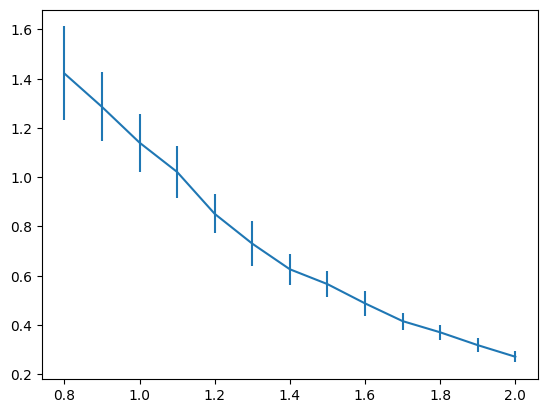

In [290]:
plt.errorbar(k, mu_true_shadow_1_4, yerr = yerr_true_shadow_1_4)

In [238]:
n_half

3.0

In [246]:
shots_list

array([  9,  12,  16,  21,  27,  36,  48,  64,  84, 111, 147, 194, 256])

In [291]:

n  = 6

n_half = n / 2

n_hgs = 10

draws = 3

shots_list = (2**(k*n)).astype(int)

shape = (8, len(noise_types), len(gammas), len(shots_list), n_hgs, draws)

distances_6 =  np.zeros( shape = shape )

for i_noise, noise_type in enumerate(noise_types):
    for i_gamma, gamma in enumerate(gammas):
        
        channel, p = sw.noise_type_gamma_to_cfg(noise_type, gamma)
        
        print(f"Running script n_eigshadow_ftransduce_surrogates_pseudo_records.py for n={n},{noise_type}, {gamma}, batch = {batch_no}, "
      f"n_hgs={n_hgs}, k_end={k[-1]}")

        for i_hg in range(n_hgs):

            past_hg = time.time()

            f_targ, w_targ = shg.sample_pseudorandom_function_hypergraph(n)

            # f_targs[:,i_hg] = f_targ

            rho_after = hnl.get_rho_after_channel(n, f_targ, channel, p)

            print(f"This is {i_hg}-th hypergraph", flush = True)

            for ishot, shots in enumerate(shots_list):

                nps = shots
    
                # variance = sw.variance_for_shadows(n, nps)
                variance = variance_for_shadows_yash(n, nps)

        
                # print(f"shot number {shots} for k {k[ishot]}", flush = True)

                for draw in range(draws):
                    
                    rho_F_shadow_surrogate_1 = sw.create_white_noise_mtd_with_density_matrix(rho_after,
            n, nps, variance,
            rng_key = None)
                    
                    rng = np.random.default_rng()
                    seed = int(rng.integers(2 ** 31 - 1))
                    key = jax.random.PRNGKey(seed)

                    rho_F_shadow_1 = hnl.get_shadow_trajectories(f_targ, shots, n, key, noise_type, gamma)
                    
                    key = jax.random.PRNGKey(seed + 10)
                    
                    rho_F_shadow_2 = hnl.get_shadow_trajectories(f_targ, shots, n, key, noise_type, gamma)
   

                    rho_F_shadow_surrogate_2 = sw.create_white_noise_mtd_with_density_matrix(rho_after,
            n, nps, variance,
            rng_key = None)

#                     D_true_shadow = tfunc.trace_dist(rho_after, rho_F_shadow)
                    
#                     D_true_surr = tfunc.trace_dist(rho_after, rho_F_shadow_surrogate)
                    
#                     D_shadow_surr = tfunc.trace_dist(rho_F_shadow, rho_F_shadow_surrogate)
                    
                    
                    D_true_shadow_1 = trace_dist_2(rho_after.real, rho_F_shadow_1.real)/(2**n_half)
            
                    # distances[0, ishot, i_hg, draw] = D_true_shadow_1
                    distances_6[0, i_noise, i_gamma, ishot, i_hg, draw] = D_true_shadow_1

            
                    D_true_shadow_2 = trace_dist_2(rho_after.real, rho_F_shadow_2.real)/(2**n_half)
                
                    # distances[1, ishot, i_hg, draw] = D_true_shadow_2
                    distances_6[1, i_noise, i_gamma, ishot, i_hg, draw] = D_true_shadow_2
                    
                    D_true_surr_1 = trace_dist_2(rho_after.real, rho_F_shadow_surrogate_1.real)/(2**n_half)
                    
                    # distances[2, ishot, i_hg, draw] = D_true_surr_1
                    distances_6[2, i_noise, i_gamma, ishot, i_hg, draw] = D_true_surr_1
                    
                    D_true_surr_2 = trace_dist_2(rho_after.real, rho_F_shadow_surrogate_2.real)/(2**n_half)
                    
                    # distances[3, ishot, i_hg, draw] = D_true_surr_2
                    distances_6[3, i_noise, i_gamma, ishot, i_hg, draw] = D_true_surr_2
                    
                    D_shadow_surr_11 = trace_dist_2(rho_F_shadow_1.real, rho_F_shadow_surrogate_1.real)/(2**n_half)
                    
                    # distances[4, ishot, i_hg, draw] = D_shadow_surr_11
                    
                    distances_6[4, i_noise, i_gamma, ishot, i_hg, draw] = D_shadow_surr_11
                                        
                    D_shadow_surr_12 = trace_dist_2(rho_F_shadow_1.real, rho_F_shadow_surrogate_2.real)/(2**n_half)
                    
                    # distances[5, ishot, i_hg, draw] = D_shadow_surr_12
                    distances_6[5, i_noise, i_gamma, ishot, i_hg, draw] = D_shadow_surr_12

                    
                    D_shadow_shadow = trace_dist_2(rho_F_shadow_1.real, rho_F_shadow_2.real)/(2**n_half)
                    
                    # distances[6, ishot, i_hg, draw] = D_shadow_shadow
                    
                    distances_6[6, i_noise, i_gamma, ishot, i_hg, draw] = D_shadow_shadow

                    
                    D_surr_surr = trace_dist_2(rho_F_shadow_surrogate_1.real, rho_F_shadow_surrogate_2.real)/(2**n_half)
                    
                    # distances[7, ishot, i_hg, draw] = D_surr_surr
                    
                    distances_6[7, i_noise, i_gamma, ishot, i_hg, draw] = D_surr_surr

   
        
                         


Running script n_eigshadow_ftransduce_surrogates_pseudo_records.py for n=6,ampdamp, 0.05, batch = 1917, n_hgs=10, k_end=2.0
This is 0-th hypergraph
This is 1-th hypergraph
This is 2-th hypergraph
This is 3-th hypergraph
This is 4-th hypergraph
This is 5-th hypergraph
This is 6-th hypergraph
This is 7-th hypergraph
This is 8-th hypergraph
This is 9-th hypergraph


In [292]:
mu_true_shadow_1_6, yerr_true_shadow_1_6 = get_stats(get_data_to_plot_2(0, distances_6, len(k) ))
mu_true_shadow_2_6, yerr_true_shadow_2_6 = get_stats(get_data_to_plot_2(1, distances_6, len(k) ))
mu_true_surr_1_6, yerr_true_surr_1_6 = get_stats(get_data_to_plot_2(2, distances_6, len(k) ))
mu_true_surr_2_6, yerr_true_surr_2_6 = get_stats(get_data_to_plot_2(3, distances_6, len(k) ))
mu_shadow_surr_11_6, yerr_shadow_surr_11_6 = get_stats(get_data_to_plot_2(4, distances_6, len(k) ))
mu_shadow_surr_12_6, yerr_shadow_surr_12_6 = get_stats(get_data_to_plot_2(5, distances_6, len(k) ))
mu_shadow_shadow_6, yerr_shadow_shadow_6 = get_stats(get_data_to_plot_2(6, distances_6, len(k) ))
mu_surr_surr_6, yerr_surr_surr_6 = get_stats(get_data_to_plot_2(7, distances_6, len(k) ))

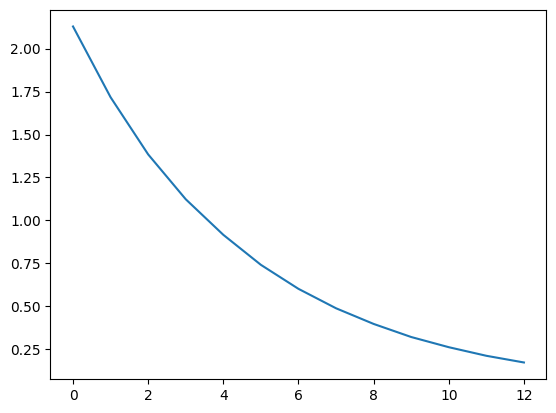

In [293]:
plt.plot(mu_true_surr_1_6)

In [29]:
def get_data_to_plot(index, benchmarks, shots_length):
    data_to_plot = [
            benchmarks[ index, i_k, :,:].flatten()
            for i_k in range(shots_length)
        ]
    return data_to_plot

In [123]:
def get_data_to_plot_2(index, benchmarks, shots_length):
    data_to_plot = [
            benchmarks[ index, :, :, i_k, :,:].flatten()
            for i_k in range(shots_length)
        ]
    return data_to_plot

In [10]:
def get_stats(data_to_plot):
    means = []
    stds = []
    for data in data_to_plot:
        means.append(np.mean(data))
        stds.append(np.std(data))

    upper_bounds = np.array(means) + np.array(stds)
    lower_bounds = np.array(means) - np.array(stds)
    # upper_bounds_clipped = np.clip(upper_bounds, 0, 1)
    # lower_bounds_clipped = np.clip(lower_bounds, 0, 1)
    yerr_upper = upper_bounds - means
    yerr_lower = means - lower_bounds

    return means, [yerr_lower, yerr_upper]


def get_data_to_plot_2(index, benchmarks, shots_length):
    data_to_plot = [
            benchmarks[ index, :, :, i_k, :,:].flatten()
            for i_k in range(shots_length)
        ]
    return data_to_plot



mu_true_shadow_1_6, yerr_true_shadow_1_6 = get_stats(get_data_to_plot_2(0, distances_6, len(k) ))
mu_true_shadow_2_6, yerr_true_shadow_2_6 = get_stats(get_data_to_plot_2(1, distances_6, len(k) ))
mu_true_surr_1_6, yerr_true_surr_1_6 = get_stats(get_data_to_plot_2(2, distances_6, len(k) ))
mu_true_surr_2_6, yerr_true_surr_2_6 = get_stats(get_data_to_plot_2(3, distances_6, len(k) ))
mu_shadow_surr_11_6, yerr_shadow_surr_11_6 = get_stats(get_data_to_plot_2(4, distances_6, len(k) ))
mu_shadow_surr_12_6, yerr_shadow_surr_12_6 = get_stats(get_data_to_plot_2(5, distances_6, len(k) ))
mu_shadow_shadow_6, yerr_shadow_shadow_6 = get_stats(get_data_to_plot_2(6, distances_6, len(k) ))
mu_surr_surr_6, yerr_surr_surr_6 = get_stats(get_data_to_plot_2(7, distances_6, len(k) ))


mu_true_shadow_1_8, yerr_true_shadow_1_8 = get_stats(get_data_to_plot_2(0, distances_8, len(k) ))
mu_true_shadow_2_8, yerr_true_shadow_2_8 = get_stats(get_data_to_plot_2(1, distances_8, len(k) ))
mu_true_surr_1_8, yerr_true_surr_1_8 = get_stats(get_data_to_plot_2(2, distances_8, len(k) ))
mu_true_surr_2_8, yerr_true_surr_2_8 = get_stats(get_data_to_plot_2(3, distances_8, len(k) ))
mu_shadow_surr_11_8, yerr_shadow_surr_11_8 = get_stats(get_data_to_plot_2(4, distances_8, len(k) ))
mu_shadow_surr_12_8, yerr_shadow_surr_12_8 = get_stats(get_data_to_plot_2(5, distances_8, len(k) ))
mu_shadow_shadow_8, yerr_shadow_shadow_8 = get_stats(get_data_to_plot_2(6, distances_8, len(k) ))
mu_surr_surr_8, yerr_surr_surr_8 = get_stats(get_data_to_plot_2(7, distances_8, len(k) ))

NameError: name 'distances_6' is not defined

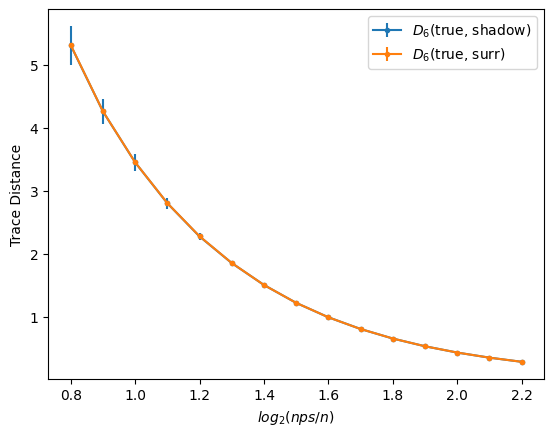

In [149]:
plt.errorbar(k, mu_true_shadow_1, yerr = yerr_true_shadow_1, fmt = '.-' )
plt.errorbar(k, mu_true_surr_1, yerr = yerr_true_surr_1, fmt = '.-'  )
plt.xlabel("$log_2(nps/n)$")
plt.ylabel("Trace Distance")
plt.legend(["$D_6$(true, shadow)", "$D_6$(true, surr)"])

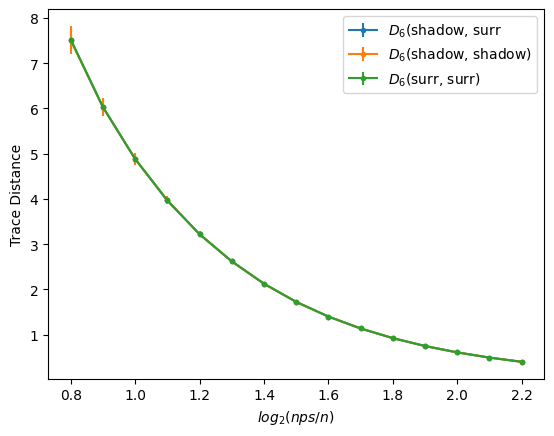

In [150]:
plt.errorbar(k, mu_shadow_surr_11, yerr = yerr_shadow_surr_11, fmt = '.-' )
plt.errorbar(k, mu_shadow_shadow, yerr = yerr_shadow_shadow, fmt = '.-' )
plt.errorbar(k, mu_surr_surr, yerr = yerr_surr_surr, fmt = '.-' )

plt.xlabel("$log_2(nps/n)$")
plt.ylabel("Trace Distance")
plt.legend(["$D_6$(shadow, surr", "$D_6$(shadow, shadow)", "$D_6$(surr, surr)"])

<ErrorbarContainer object of 3 artists>

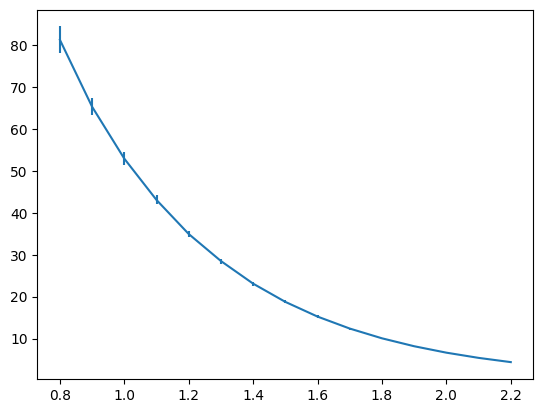

In [59]:
plt.errorbar(k, mu_shadow_surr_11, yerr = yerr_shadow_surr_11 )


In [30]:
sw = importlib.reload(sw)
hnl = importlib.reload(hnl)

In [131]:
f_targ, w_targ = shg.sample_pseudorandom_function_hypergraph(8)

# f_targs[:,i_hg] = f_targ

rho_after = hnl.get_rho_after_channel(8, f_targ, channel, p)

# print(f"This is {i_hg}-th hypergraph", flush = True)

# for ishot, shots in enumerate(shots_list):

nps = 2**(k*8).astype(int)[0]

# variance = sw.variance_for_shadows(n, nps)
variance = variance_for_shadows_yash(8, nps)


# print(f"shot number {shots} for k {k[ishot]}", flush = True)

# for draw in range(draws):

rho_F_shadow_surrogate_1 = sw.create_white_noise_mtd_with_density_matrix(rho_after,
8, nps, variance,
rng_key = None)

In [132]:
trace_dist_2(rho_after, rho_F_shadow_surrogate_1)/(2**4)

Array(3.4491198, dtype=float32)

In [135]:
f_targ, w_targ = shg.sample_pseudorandom_function_hypergraph(6)

# f_targs[:,i_hg] = f_targ

rho_after = hnl.get_rho_after_channel(6, f_targ, channel, p)

# print(f"This is {i_hg}-th hypergraph", flush = True)

# for ishot, shots in enumerate(shots_list):

nps = shots_list[0]

# variance = sw.variance_for_shadows(n, nps)
variance = variance_for_shadows_yash(6, nps)


# print(f"shot number {shots} for k {k[ishot]}", flush = True)

# for draw in range(draws):

rho_F_shadow_surrogate_1 = sw.create_white_noise_mtd_with_density_matrix(rho_after,
6, nps, variance,
rng_key = None)

In [136]:
trace_dist_2(rho_after, rho_F_shadow_surrogate_1)/(2**3)

Array(2.135431, dtype=float32)

In [137]:
nps

27

In [82]:
@jax.jit
def trace_dist_2(A,B):
    """
    Calculate the operator 2-norm.

    Args:
        R (array): The operator whose norm we want to calculate.

    Returns:
        Scalar corresponding to the norm.
    """
    R = A - B
    return jnp.sqrt(jnp.trace(R.conjugate().transpose() @ R)).real

In [114]:
trace_dist_2(rho_after, rho_F_shadow_surrogate_1)/(2**6)

Array(0.25845736, dtype=float32)

In [90]:
psi_f = sw.f2psi_f(f_targ)

rho_f = jnp.outer(psi_f.conj(), psi_f )

In [91]:
trace_dist_2(rho_after, rho_f)

Array(0.15439984, dtype=float32)

In [213]:
draws

3

In [219]:
noise_types = ['ampdamp']

gammas = [5e-2]

In [222]:
k = np.array([0.8, 0.9, 1.0 , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0])

In [294]:
n = 8

n_half = n / 2

n_hgs = 10

draws = 3

shots_list = (2**(k*n)).astype(int)

shape = (8, len(noise_types), len(gammas), len(shots_list), n_hgs, draws)

distances_8 =  np.zeros( shape = shape )


for i_noise, noise_type in enumerate(noise_types):
    for i_gamma, gamma in enumerate(gammas):
        
        channel, p = sw.noise_type_gamma_to_cfg(noise_type, gamma)


        
        print(f"Running script n_eigshadow_ftransduce_surrogates_pseudo_records.py for n={n},{noise_type}, {gamma}, batch = {batch_no}, "
      f"n_hgs={n_hgs}, k_end={k[-1]}")

        for i_hg in range(n_hgs):

            past_hg = time.time()

            f_targ, w_targ = shg.sample_pseudorandom_function_hypergraph(n)


            rho_after = hnl.get_rho_after_channel(n, f_targ, channel, p)

            print(f"This is {i_hg}-th hypergraph", flush = True)

            for ishot, shots in enumerate(shots_list):

                nps = shots
    
                # variance = sw.variance_for_shadows(n, nps)
                variance = variance_for_shadows_yash(n, nps)

        
                # print(f"shot number {shots} for k {k[ishot]}", flush = True)

                for draw in range(draws):
                    
                    rho_F_shadow_surrogate_1 = sw.create_white_noise_mtd_with_density_matrix(rho_after,
            n, nps, variance,
            rng_key = None)
                    
                    rng = np.random.default_rng()
                    seed = int(rng.integers(2 ** 31 - 1))
                    key = jax.random.PRNGKey(seed)

                    rho_F_shadow_1 = hnl.get_shadow_trajectories(f_targ, shots, n, key, noise_type, gamma)
                    
                    key = jax.random.PRNGKey(seed + 10)
                    
                    rho_F_shadow_2 = hnl.get_shadow_trajectories(f_targ, shots, n, key, noise_type, gamma)
   

                    rho_F_shadow_surrogate_2 = sw.create_white_noise_mtd_with_density_matrix(rho_after,
            n, nps, variance,
            rng_key = None)

#                     D_true_shadow = tfunc.trace_dist(rho_after, rho_F_shadow)
                    
#                     D_true_surr = tfunc.trace_dist(rho_after, rho_F_shadow_surrogate)
                    
#                     D_shadow_surr = tfunc.trace_dist(rho_F_shadow, rho_F_shadow_surrogate)
                    
                    
                    D_true_shadow_1 = trace_dist_2(rho_after.real, rho_F_shadow_1.real)/(2**n_half)
            
                    # distances[0, ishot, i_hg, draw] = D_true_shadow_1
                    distances_8[0, i_noise, i_gamma, ishot, i_hg, draw] = D_true_shadow_1

            
                    D_true_shadow_2 = trace_dist_2(rho_after.real, rho_F_shadow_2.real)/(2**n_half)
                
                    # distances[1, ishot, i_hg, draw] = D_true_shadow_2
                    distances_8[1, i_noise, i_gamma, ishot, i_hg, draw] = D_true_shadow_2
                    
                    D_true_surr_1 = trace_dist_2(rho_after.real, rho_F_shadow_surrogate_1.real)/(2**n_half)
                    
                    # distances[2, ishot, i_hg, draw] = D_true_surr_1
                    distances_8[2, i_noise, i_gamma, ishot, i_hg, draw] = D_true_surr_1
                    
                    D_true_surr_2 = trace_dist_2(rho_after.real, rho_F_shadow_surrogate_2.real)/(2**n_half)
                    
                    # distances[3, ishot, i_hg, draw] = D_true_surr_2
                    distances_8[3, i_noise, i_gamma, ishot, i_hg, draw] = D_true_surr_2
                    
                    D_shadow_surr_11 = trace_dist_2(rho_F_shadow_1.real, rho_F_shadow_surrogate_1.real)/(2**n_half)
                    
                    # distances[4, ishot, i_hg, draw] = D_shadow_surr_11
                    
                    distances_8[4, i_noise, i_gamma, ishot, i_hg, draw] = D_shadow_surr_11
                                        
                    D_shadow_surr_12 = trace_dist_2(rho_F_shadow_1.real, rho_F_shadow_surrogate_2.real)/(2**n_half)
                    
                    # distances[5, ishot, i_hg, draw] = D_shadow_surr_12
                    distances_8_[5, i_noise, i_gamma, ishot, i_hg, draw] = D_shadow_surr_12

                    
                    D_shadow_shadow = trace_dist_2(rho_F_shadow_1.real, rho_F_shadow_2.real)/(2**n_half)
                    
                    # distances[6, ishot, i_hg, draw] = D_shadow_shadow
                    
                    distances_8[6, i_noise, i_gamma, ishot, i_hg, draw] = D_shadow_shadow

                    
                    D_surr_surr = trace_dist_2(rho_F_shadow_surrogate_1.real, rho_F_shadow_surrogate_2.real)/(2**n_half)
                    
                    # distances[7, ishot, i_hg, draw] = D_surr_surr
                    
                    distances_8[7, i_noise, i_gamma, ishot, i_hg, draw] = D_surr_surr

                    




Running script n_eigshadow_ftransduce_surrogates_pseudo_records.py for n=8,ampdamp, 0.05, batch = 1917, n_hgs=10, k_end=2.0
This is 0-th hypergraph
This is 1-th hypergraph
This is 2-th hypergraph
This is 3-th hypergraph
This is 4-th hypergraph
This is 5-th hypergraph
This is 6-th hypergraph
This is 7-th hypergraph
This is 8-th hypergraph
This is 9-th hypergraph


In [204]:
D_true_shadow_1

Array(0.7113237, dtype=float32)

In [241]:
shots_list

array([   84,   147,   256,   445,   776,  1351,  2352,  4096,  7131,
       12416, 21618, 37640, 65536])

In [307]:


n_hgs = 10

draws = 3

n  = 10

n_half = n / 2

n_hgs = 10

draws = 3

shots_list = (2**(k*n)).astype(int)

shape = (8, len(noise_types), len(gammas), len(shots_list), n_hgs, draws)

distances_10 =  np.zeros( shape = shape )
for i_noise, noise_type in enumerate(noise_types):
    for i_gamma, gamma in enumerate(gammas):
        
        channel, p = sw.noise_type_gamma_to_cfg(noise_type, gamma)

        # distances =  np.zeros( shape = shape )
        
        # f_benchmarks = np.zeros(shape = f_bench_shape, dtype = int)

        # f_targs = np.zeros(shape = f_targs_shape, dtype = int)

        
        
        # noise_path = qubit_dir / f"ftransduce_{name}_qubit_{n}_batch_{batch_no}_hgs_{n_hgs}_draws_{draws}_{noise_type}_{gamma}"

        # noise_bench = str(noise_path) + f"_noise_bench.npy"

        # algo_bench = str(noise_path) + f"_algo_bench.npy"

        # ftargs = str(noise_path) + f"_f_targs.npy"

        # fbenchmarks = str(noise_path) + f"_f_benchmarks.npy"
        
        print(f"Running script n_eigshadow_ftransduce_surrogates_pseudo_records.py for n={n},{noise_type}, {gamma}, batch = {batch_no}, "
      f"n_hgs={n_hgs}, k_end={k[-1]}")

        for i_hg in range(n_hgs):

            past_hg = time.time()

            f_targ, w_targ = shg.sample_pseudorandom_function_hypergraph(n)

            # f_targs[:,i_hg] = f_targ

            rho_after = hnl.get_rho_after_channel(n, f_targ, channel, p)

            print(f"This is {i_hg}-th hypergraph", flush = True)

            for ishot, shots in enumerate(shots_list):

                nps = shots
    
                # variance = sw.variance_for_shadows(n, nps)
                variance = variance_for_shadows_yash(n, nps)

        
                # print(f"shot number {shots} for k {k[ishot]}", flush = True)

                for draw in range(draws):
                    
                    rho_F_shadow_surrogate_1 = sw.create_white_noise_mtd_with_density_matrix(rho_after,
            n, nps, variance,
            rng_key = None)
                    
                    rng = np.random.default_rng()
                    seed = int(rng.integers(2 ** 31 - 1))
                    key = jax.random.PRNGKey(seed)

                    rho_F_shadow_1 = hnl.get_shadow_trajectories(f_targ, shots, n, key, noise_type, gamma)
                    
                    key = jax.random.PRNGKey(seed + 10)
                    
                    rho_F_shadow_2 = hnl.get_shadow_trajectories(f_targ, shots, n, key, noise_type, gamma)
   

                    rho_F_shadow_surrogate_2 = sw.create_white_noise_mtd_with_density_matrix(rho_after,
            n, nps, variance,
            rng_key = None)

#                     D_true_shadow = tfunc.trace_dist(rho_after, rho_F_shadow)
                    
#                     D_true_surr = tfunc.trace_dist(rho_after, rho_F_shadow_surrogate)
                    
#                     D_shadow_surr = tfunc.trace_dist(rho_F_shadow, rho_F_shadow_surrogate)
                    
                    
                    D_true_shadow_1 = trace_dist_2(rho_after.real, rho_F_shadow_1.real)/(2**n_half)
            
                    # distances[0, ishot, i_hg, draw] = D_true_shadow_1
                    distances_10[0, i_noise, i_gamma, ishot, i_hg, draw] = D_true_shadow_1

            
                    # D_true_shadow_2 = trace_dist_2(rho_after.real, rho_F_shadow_2.real)/(2**n_half)
                
                    # distances[1, ishot, i_hg, draw] = D_true_shadow_2
                    # distances_10[1, i_noise, i_gamma, ishot, i_hg, draw] = D_true_shadow_2
                    
                    D_true_surr_1 = trace_dist_2(rho_after.real, rho_F_shadow_surrogate_1.real)/(2**n_half)
                    
                    # distances[2, ishot, i_hg, draw] = D_true_surr_1
                    distances_10[2, i_noise, i_gamma, ishot, i_hg, draw] = D_true_surr_1
                    
                    D_true_surr_2 = trace_dist_2(rho_after.real, rho_F_shadow_surrogate_2.real)/(2**n_half)
                    
                    # distances[3, ishot, i_hg, draw] = D_true_surr_2
                    distances_10[3, i_noise, i_gamma, ishot, i_hg, draw] = D_true_surr_2
                    
                    D_shadow_surr_11 = trace_dist_2(rho_F_shadow_1.real, rho_F_shadow_surrogate_1.real)/(2**n_half)
                    
                    # distances[4, ishot, i_hg, draw] = D_shadow_surr_11
                    
                    distances_10[4, i_noise, i_gamma, ishot, i_hg, draw] = D_shadow_surr_11
                                        
                    D_shadow_surr_12 = trace_dist_2(rho_F_shadow_1.real, rho_F_shadow_surrogate_2.real)/(2**n_half)
                    
                    # distances[5, ishot, i_hg, draw] = D_shadow_surr_12
                    distances_10[5, i_noise, i_gamma, ishot, i_hg, draw] = D_shadow_surr_12

                    
                    D_shadow_shadow = trace_dist_2(rho_F_shadow_1.real, rho_F_shadow_2.real)/(2**n_half)
                    
                    # distances[6, ishot, i_hg, draw] = D_shadow_shadow
                    
                    distances_10[6, i_noise, i_gamma, ishot, i_hg, draw] = D_shadow_shadow

                    
                    D_surr_surr = trace_dist_2(rho_F_shadow_surrogate_1.real, rho_F_shadow_surrogate_2.real)/(2**n_half)
                    
                    # distances[7, ishot, i_hg, draw] = D_surr_surr
                    
                    distances_10[7, i_noise, i_gamma, ishot, i_hg, draw] = D_surr_surr

   
        
                         


Running script n_eigshadow_ftransduce_surrogates_pseudo_records.py for n=10,ampdamp, 0.05, batch = 1917, n_hgs=10, k_end=2.0
This is 0-th hypergraph
This is 1-th hypergraph
This is 2-th hypergraph
This is 5-th hypergraph
This is 6-th hypergraph
This is 7-th hypergraph
This is 8-th hypergraph
This is 9-th hypergraph


In [11]:
np.save(f"paper_data/shadow_surrogate_comparison/distances_4.npy", distances_4 )

np.save(f"paper_data/shadow_surrogate_comparison/distances_6.npy", distances_6 )

np.save(f"paper_data/shadow_surrogate_comparison/distances_8.npy", distances_8 )

np.save(f"paper_data/shadow_surrogate_comparison/distances_10.npy", distances_10 )

FileNotFoundError: [Errno 2] No such file or directory: 'paper_data/shadow_surrogate_comparison/distances_4.npy'

In [ ]:
distances_8 = np.load("distances_8.npy")


In [1]:
import numpy as np

# index map in your arrays
CASE_TO_INDICES = {
    "true": [0, 1, 2, 3],          # true-shadow and true-surrogate
    "shadow_surr": [4, 5],         # shadow vs surrogate
    "shadow_shadow": [6],          # shadow vs shadow
    # "surr_surr": [7],            # optional extra case
}

def valid_channel(arr, idx):
    # skip channels that were never populated (all zeros)
    return not np.all(arr[idx] == 0)

def reconstruct_mu_std_by_case(distances, case_to_indices=CASE_TO_INDICES):
    """
    Returns:
      per_shot[case]["mu"], per_shot[case]["std"]  -> arrays of len(shots)
      global_[case]["mu"], global_[case]["std"]    -> scalars over all shots
    """
    shots_len = distances.shape[3]
    per_shot = {}
    global_ = {}

    for case, idxs in case_to_indices.items():
        idxs = [i for i in idxs if valid_channel(distances, i)]
        if not idxs:
            per_shot[case] = {"mu": np.full(shots_len, np.nan), "std": np.full(shots_len, np.nan)}
            global_[case] = {"mu": np.nan, "std": np.nan}
            continue

        mu = np.zeros(shots_len)
        std = np.zeros(shots_len)
        all_vals = []

        for i_k in range(shots_len):
            # same slicing pattern as get_data_to_plot_2: [idx, :, :, i_k, :, :]
            vals = np.concatenate([distances[i, :, :, i_k, :, :].ravel() for i in idxs])
            mu[i_k] = np.mean(vals)
            std[i_k] = np.std(vals)
            all_vals.append(vals)

        all_vals = np.concatenate(all_vals)
        per_shot[case] = {"mu": mu, "std": std}
        global_[case] = {"mu": np.mean(all_vals), "std": np.std(all_vals)}

    return per_shot, global_

In [2]:
distances_6 = np.load("distances_6.npy")    
distances_8 = np.load("distances_8.npy")    
distances_10 = np.load("distances_10.npy")    



stats6, global6 = reconstruct_mu_std_by_case(distances_6)
stats8, global8 = reconstruct_mu_std_by_case(distances_8)
stats10, global10 = reconstruct_mu_std_by_case(distances_10)

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
# Match style used in figures_notebooks/fig4_nps_nq_alpha_ch.ipynb
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / '.git').exists():
REPO_ROOT = REPO_ROOT.parent
plt.style.use(str(REPO_ROOT / 'figures_notebooks' / 'single_column.mplstyle'))
def _load_distances_for_n(nq):
candidates = [
  REPO_ROOT / 'paper_data' / 'shadow_surrogate_comparison' / f'distances_{nq}.npy',
  REPO_ROOT / 'surogate' / f'distances_{nq}.npy',
]
for p in candidates:
  if p.exists():
      return np.load(p)
raise FileNotFoundError(f'Could not find distances_{nq}.npy in known locations.')
def _channel_is_valid(arr, idx):
# Some channels are unfilled in saved arrays; skip all-zero channels.
return not np.all(arr[idx] == 0)
def _reconstruct_case_mu_std(arr, case_to_indices):
shots_len = arr.shape[3]
out = {}
for case, idxs in case_to_indices.items():
  valid_idxs = [i for i in idxs if _channel_is_valid(arr, i)]
  mu = np.full(shots_len, np.nan)
  std = np.full(shots_len, np.nan)
  for i_k in range(shots_len):
      if valid_idxs:
          vals = np.concatenate([arr[i, :, :, i_k, :, :].ravel() for i in valid_idxs])
          mu[i_k] = np.mean(vals)
          std[i_k] = np.std(vals)
  out[case] = {'mu': mu, 'std': std, 'valid_channels': valid_idxs}
return out
CASE_TO_INDICES = {
'true': [0, 1, 2, 3],
'shadow_surr': [4, 5],
'shadow_shadow': [6],
}
# Load (or reuse) distances arrays
if 'distances_6' not in globals():
distances_6 = _load_distances_for_n(6)
if 'distances_8' not in globals():
distances_8 = _load_distances_for_n(8)
if 'distances_10' not in globals():
distances_10 = _load_distances_for_n(10)
stats_by_n = {
6: _reconstruct_case_mu_std(distances_6, CASE_TO_INDICES),
8: _reconstruct_case_mu_std(distances_8, CASE_TO_INDICES),
10: _reconstruct_case_mu_std(distances_10, CASE_TO_INDICES),
}
# Compact style-consistent plot
fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.4), sharey=True, gridspec_kw={'wspace': 0.08})
case_style = {
'true': ('-', '#1f77b4', 'true'),
'shadow_surr': ('--', '#2ca02c', 'shadow_surr'),
'shadow_shadow': (':', '#d62728', 'shadow_shadow'),
}
for ax, nq in zip(axes, [6, 8, 10]):
x = np.arange(stats_by_n[nq]['true']['mu'].shape[0])
for case, (ls, color, label) in case_style.items():
  mu = stats_by_n[nq][case]['mu']
  std = stats_by_n[nq][case]['std']
  ax.plot(x, mu, ls=ls, color=color, lw=1.5)
  ax.fill_between(x, mu - std, mu + std, color=color, alpha=0.18, linewidth=0)
ax.set_title(rf'$n_q={nq}$')
ax.set_xlabel('shot index')
ax.grid(True, alpha=0.3)
axes[0].set_ylabel('trace distance')
legend_handles = [
mlines.Line2D([0], [0], color=c, ls=ls, lw=1.5, label=lab)
for _, (ls, c, lab) in case_style.items()
]
axes[-1].legend(handles=legend_handles, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


IndentationError: expected an indented block (94489668.py, line 8)

In [14]:
mu_true_shadow_1_8, yerr_true_shadow_1_8 = get_stats(get_data_to_plot_2(0, distances_8, len(k) ))
mu_true_shadow_2_8, yerr_true_shadow_2_8 = get_stats(get_data_to_plot_2(1, distances_8, len(k) ))
mu_true_surr_1_8, yerr_true_surr_1_8 = get_stats(get_data_to_plot_2(2, distances_8, len(k) ))
mu_true_surr_2_8, yerr_true_surr_2_8 = get_stats(get_data_to_plot_2(3, distances_8, len(k) ))
mu_shadow_surr_11_8, yerr_shadow_surr_11_8 = get_stats(get_data_to_plot_2(4, distances_8, len(k) ))
mu_shadow_surr_12_8, yerr_shadow_surr_12_8 = get_stats(get_data_to_plot_2(5, distances_8, len(k) ))
mu_shadow_shadow_8, yerr_shadow_shadow_8 = get_stats(get_data_to_plot_2(6, distances_8, len(k) ))
mu_surr_surr_8, yerr_surr_surr_8 = get_stats(get_data_to_plot_2(7, distances_8, len(k) ))

IndexError: index 13 is out of bounds for axis 3 with size 13

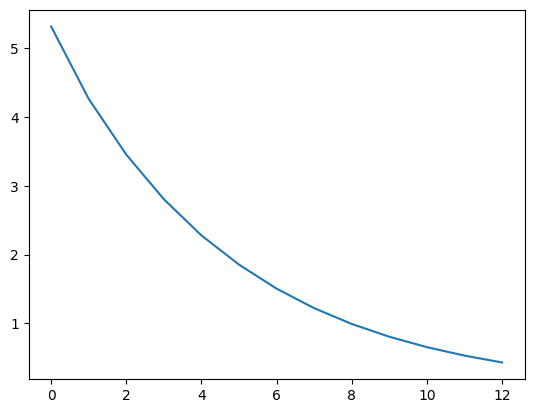

In [244]:
plt.plot(mu_true_surr_1_8)

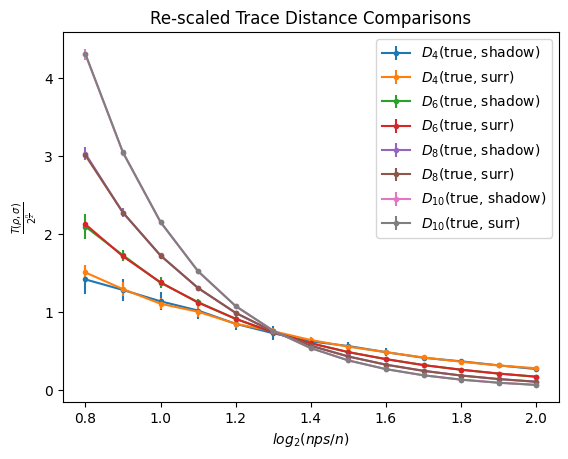

In [326]:
plt.errorbar(k, np.array(mu_true_shadow_1_4), yerr = yerr_true_shadow_1_4, fmt = '.-' )
plt.errorbar(k, np.array(mu_true_surr_1_4), yerr = yerr_true_surr_1_4, fmt = '.-'  )

plt.errorbar(k, np.array(mu_true_shadow_1_6), yerr = yerr_true_shadow_1_6, fmt = '.-' )
plt.errorbar(k, np.array(mu_true_surr_1_6), yerr = yerr_true_surr_1_6, fmt = '.-'  )

plt.errorbar(k, np.array(mu_true_shadow_1_8), yerr = yerr_true_shadow_1_8, fmt = '.-' )
plt.errorbar(k, np.array(mu_true_surr_1_8), yerr = yerr_true_surr_1_8, fmt = '.-'  )

plt.errorbar(k, np.array(mu_true_shadow_1_10), yerr = yerr_true_shadow_1_10, fmt = '.-' )
plt.errorbar(k, np.array(mu_true_surr_1_10), yerr = yerr_true_surr_1_10, fmt = '.-'  )
plt.xlabel("$log_2(nps/n)$")
plt.ylabel(r"$\frac{T(\rho,\sigma)}{2^{\frac{n}{2}}}$")
plt.title("Re-scaled Trace Distance Comparisons")
plt.legend(["$D_4$(true, shadow)", "$D_4$(true, surr)",
            "$D_6$(true, shadow)", "$D_6$(true, surr)",
            "$D_8$(true, shadow)", "$D_8$(true, surr)",
            "$D_{10}$(true, shadow)", "$D_{10}$(true, surr)"])

plt.savefig("True_Shadow_Surr_distances.pdf", format='pdf', bbox_inches='tight')

plt.show()

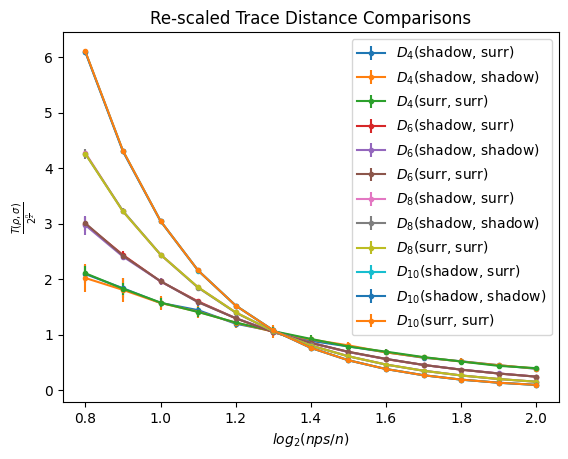

In [327]:
plt.errorbar(k, mu_shadow_surr_11_4, yerr = yerr_shadow_surr_11_4, fmt = '.-' )
plt.errorbar(k, mu_shadow_shadow_4, yerr = yerr_shadow_shadow_4, fmt = '.-' )
plt.errorbar(k, mu_surr_surr_4, yerr = yerr_surr_surr_4, fmt = '.-' )

plt.errorbar(k, mu_shadow_surr_11_6, yerr = yerr_shadow_surr_11_6, fmt = '.-' )
plt.errorbar(k, mu_shadow_shadow_6, yerr = yerr_shadow_shadow_6, fmt = '.-' )
plt.errorbar(k, mu_surr_surr_6, yerr = yerr_surr_surr_6, fmt = '.-' )

plt.errorbar(k, mu_shadow_surr_11_8, yerr = yerr_shadow_surr_11_8, fmt = '.-' )
plt.errorbar(k, mu_shadow_shadow_8, yerr = yerr_shadow_shadow_8, fmt = '.-' )
plt.errorbar(k, mu_surr_surr_8, yerr = yerr_surr_surr_8, fmt = '.-' )

plt.errorbar(k, mu_shadow_surr_11_10, yerr = yerr_shadow_surr_11_10, fmt = '.-' )
plt.errorbar(k, mu_shadow_shadow_10, yerr = yerr_shadow_shadow_10, fmt = '.-' )
plt.errorbar(k, mu_surr_surr_10, yerr = yerr_surr_surr_10, fmt = '.-' )

plt.xlabel("$log_2(nps/n)$")
plt.ylabel(r"$\frac{T(\rho,\sigma)}{2^{\frac{n}{2}}}$")
plt.title("Re-scaled Trace Distance Comparisons")
plt.legend(["$D_4$(shadow, surr)", "$D_4$(shadow, shadow)", "$D_4$(surr, surr)" ,
            "$D_6$(shadow, surr)", "$D_6$(shadow, shadow)", "$D_6$(surr, surr)" ,
            "$D_8$(shadow, surr)", "$D_8$(shadow, shadow)", "$D_8$(surr, surr)",
            "$D_{10}$(shadow, surr)", "$D_{10}$(shadow, shadow)", "$D_{10}$(surr, surr)"])

plt.savefig("Shadow_Surr_Permutations_distances.pdf", format='pdf', bbox_inches='tight')

plt.show()

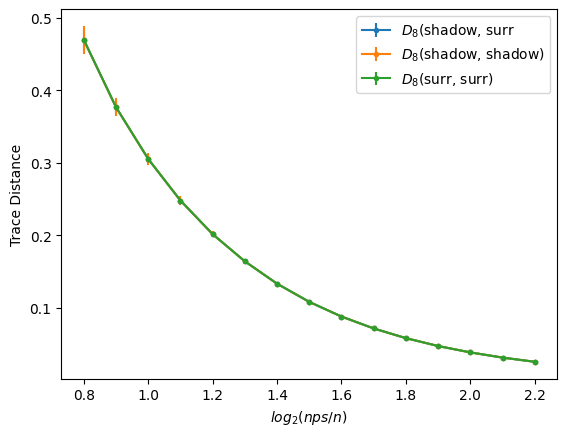

In [211]:
plt.errorbar(k, mu_shadow_surr_11_8, yerr = yerr_shadow_surr_11_8, fmt = '.-' )
plt.errorbar(k, mu_shadow_shadow_8, yerr = yerr_shadow_shadow_8, fmt = '.-' )
plt.errorbar(k, mu_surr_surr_8, yerr = yerr_surr_surr_8, fmt = '.-' )

plt.xlabel("$log_2(nps/n)$")
plt.ylabel("Trace Distance")
plt.legend(["$D_8$(shadow, surr", "$D_8$(shadow, shadow)", "$D_8$(surr, surr)"])

In [196]:
mu_true_shadow_1_10

[0.025994837284088135,
 0.020815502714227746,
 0.016812225758891415,
 0.01366924765623278,
 0.011114650067907792,
 0.00904557989841258,
 0.0073505706722951595,
 0.005968664655530895,
 0.004840705997345073,
 0.00393597375670517,
 0.0031952588534396556,
 0.0025952316949971847,
 0.002107838060948308,
 0.001711307322451224,
 0.0013908128344660832]

Text(0, 0.5, 'Trace Distance')

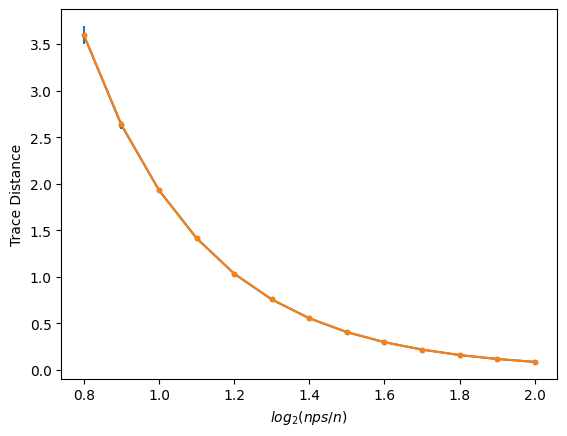

In [297]:
plt.errorbar(k, mu_true_shadow_1_10, yerr = yerr_true_shadow_1_10, fmt = '.-' )
plt.errorbar(k, mu_true_surr_1_10, yerr = yerr_true_surr_1_10, fmt = '.-'  )
plt.xlabel("$log_2(nps/n)$")
plt.ylabel("Trace Distance")
# plt.legend(["$D_8$(true, shadow)", "$D_8$(true, surr)"])

In [249]:
def get_data_to_plot_scaled_inv(index, benchmarks, shots_length, n):
    """
    Extracts data and applies the 1/2**n scaling.
    If your raw 'benchmarks' are already pre-scaled by 1/2**(n/2), 
    this function multiplies by 2**(n/2) to undo it, then applies 1/2**n.
    Simplified: it applies a multiplier of 2**(-n/2).
    """
    # Correction factor to go from 1/2**(n/2) -> 1/2**n
    correction =  (2**(n/2)) 
    
    data_to_plot = [
        benchmarks[index, :, :, i_k, :, :].flatten() * correction
        for i_k in range(shots_length)
    ]
    return data_to_plot

In [167]:


def get_data_to_plot_scaled(index, benchmarks, shots_length, n):
    """
    Extracts data and applies the 1/2**n scaling.
    If your raw 'benchmarks' are already pre-scaled by 1/2**(n/2), 
    this function multiplies by 2**(n/2) to undo it, then applies 1/2**n.
    Simplified: it applies a multiplier of 2**(-n/2).
    """
    # Correction factor to go from 1/2**(n/2) -> 1/2**n
    correction = 1 / (2**(n/2)) 
    
    data_to_plot = [
        benchmarks[index, :, :, i_k, :, :].flatten() * correction
        for i_k in range(shots_length)
    ]
    return data_to_plot

In [315]:
n4 = 4
data_4 = lambda idx: get_data_to_plot_scaled(idx, distances_4, len(k), n4)

mu_true_shadow_1_4, yerr_true_shadow_1_4 = get_stats(data_4(0))
mu_true_shadow_2_4, yerr_true_shadow_2_4 = get_stats(data_4(1))
mu_true_surr_1_4, yerr_true_surr_1_4     = get_stats(data_4(2))
mu_true_surr_2_4, yerr_true_surr_2_4     = get_stats(data_4(3))
mu_shadow_surr_11_4, yerr_shadow_surr_11_4 = get_stats(data_4(4))
mu_shadow_surr_12_4, yerr_shadow_surr_12_4 = get_stats(data_4(5))
mu_shadow_shadow_4, yerr_shadow_shadow_4 = get_stats(data_4(6))
mu_surr_surr_4, yerr_surr_surr_4         = get_stats(data_4(7))

# --- Process n = 6 ---
# Correction factor here is 1 / 2^3 = 0.125
n6 = 6
data_6 = lambda idx: get_data_to_plot_scaled(idx, distances_6, len(k), n6)

mu_true_shadow_1_6, yerr_true_shadow_1_6 = get_stats(data_6(0))
mu_true_shadow_2_6, yerr_true_shadow_2_6 = get_stats(data_6(1))
mu_true_surr_1_6, yerr_true_surr_1_6     = get_stats(data_6(2))
mu_true_surr_2_6, yerr_true_surr_2_6     = get_stats(data_6(3))
mu_shadow_surr_11_6, yerr_shadow_surr_11_6 = get_stats(data_6(4))
mu_shadow_surr_12_6, yerr_shadow_surr_12_6 = get_stats(data_6(5))
mu_shadow_shadow_6, yerr_shadow_shadow_6 = get_stats(data_6(6))
mu_surr_surr_6, yerr_surr_surr_6         = get_stats(data_6(7))

# --- Process n = 8 ---
# Correction factor here is 1 / 2^4 = 0.0625
n8 = 8
data_8 = lambda idx: get_data_to_plot_scaled(idx, distances_8, len(k), n8)

mu_true_shadow_1_8, yerr_true_shadow_1_8 = get_stats(data_8(0))
mu_true_shadow_2_8, yerr_true_shadow_2_8 = get_stats(data_8(1))
mu_true_surr_1_8, yerr_true_surr_1_8     = get_stats(data_8(2))
mu_true_surr_2_8, yerr_true_surr_2_8     = get_stats(data_8(3))
mu_shadow_surr_11_8, yerr_shadow_surr_11_8 = get_stats(data_8(4))
mu_shadow_surr_12_8, yerr_shadow_surr_12_8 = get_stats(data_8(5))
mu_shadow_shadow_8, yerr_shadow_shadow_8 = get_stats(data_8(6))
mu_surr_surr_8, yerr_surr_surr_8         = get_stats(data_8(7))

n10 = 10
data_10 = lambda idx: get_data_to_plot_scaled(idx, distances_10, len(k), n10)

mu_true_shadow_1_10, yerr_true_shadow_1_10 = get_stats(data_10(0))
mu_true_shadow_2_10, yerr_true_shadow_2_10 = get_stats(data_10(1))
mu_true_surr_1_10, yerr_true_surr_1_10     = get_stats(data_10(2))
mu_true_surr_2_10, yerr_true_surr_2_10     = get_stats(data_10(3))
mu_shadow_surr_11_10, yerr_shadow_surr_11_10 = get_stats(data_10(4))
mu_shadow_surr_12_10, yerr_shadow_surr_12_10 = get_stats(data_10(5))
mu_shadow_shadow_10, yerr_shadow_shadow_10 = get_stats(data_10(6))
mu_surr_surr_10, yerr_surr_surr_10         = get_stats(data_10(7))



In [318]:
n4 = 4
data_4 = lambda idx: get_data_to_plot_scaled_inv(idx, distances_4, len(k), n4)

mu_true_shadow_1_4, yerr_true_shadow_1_4 = get_stats(data_4(0))
mu_true_shadow_2_4, yerr_true_shadow_2_4 = get_stats(data_4(1))
mu_true_surr_1_4, yerr_true_surr_1_4     = get_stats(data_4(2))
mu_true_surr_2_4, yerr_true_surr_2_4     = get_stats(data_4(3))
mu_shadow_surr_11_4, yerr_shadow_surr_11_4 = get_stats(data_4(4))
mu_shadow_surr_12_4, yerr_shadow_surr_12_4 = get_stats(data_4(5))
mu_shadow_shadow_4, yerr_shadow_shadow_4 = get_stats(data_4(6))
mu_surr_surr_4, yerr_surr_surr_4         = get_stats(data_4(7))

# --- Process n = 6 ---
# Correction factor here is 1 / 2^3 = 0.125
n6 = 6
data_6 = lambda idx: get_data_to_plot_scaled_inv(idx, distances_6, len(k), n6)

mu_true_shadow_1_6, yerr_true_shadow_1_6 = get_stats(data_6(0))
mu_true_shadow_2_6, yerr_true_shadow_2_6 = get_stats(data_6(1))
mu_true_surr_1_6, yerr_true_surr_1_6     = get_stats(data_6(2))
mu_true_surr_2_6, yerr_true_surr_2_6     = get_stats(data_6(3))
mu_shadow_surr_11_6, yerr_shadow_surr_11_6 = get_stats(data_6(4))
mu_shadow_surr_12_6, yerr_shadow_surr_12_6 = get_stats(data_6(5))
mu_shadow_shadow_6, yerr_shadow_shadow_6 = get_stats(data_6(6))
mu_surr_surr_6, yerr_surr_surr_6         = get_stats(data_6(7))

# --- Process n = 8 ---
# Correction factor here is 1 / 2^4 = 0.0625
n8 = 8
data_8 = lambda idx: get_data_to_plot_scaled_inv(idx, distances_8, len(k), n8)

mu_true_shadow_1_8, yerr_true_shadow_1_8 = get_stats(data_8(0))
mu_true_shadow_2_8, yerr_true_shadow_2_8 = get_stats(data_8(1))
mu_true_surr_1_8, yerr_true_surr_1_8     = get_stats(data_8(2))
mu_true_surr_2_8, yerr_true_surr_2_8     = get_stats(data_8(3))
mu_shadow_surr_11_8, yerr_shadow_surr_11_8 = get_stats(data_8(4))
mu_shadow_surr_12_8, yerr_shadow_surr_12_8 = get_stats(data_8(5))
mu_shadow_shadow_8, yerr_shadow_shadow_8 = get_stats(data_8(6))
mu_surr_surr_8, yerr_surr_surr_8         = get_stats(data_8(7))


n10 = 10
data_10 = lambda idx: get_data_to_plot_scaled_inv(idx, distances_10, len(k), n10)

mu_true_shadow_1_10, yerr_true_shadow_1_10 = get_stats(data_10(0))
mu_true_shadow_2_10, yerr_true_shadow_2_10 = get_stats(data_10(1))
mu_true_surr_1_10, yerr_true_surr_1_10     = get_stats(data_10(2))
mu_true_surr_2_10, yerr_true_surr_2_10     = get_stats(data_10(3))
mu_shadow_surr_11_10, yerr_shadow_surr_11_10 = get_stats(data_10(4))
mu_shadow_surr_12_10, yerr_shadow_surr_12_10 = get_stats(data_10(5))
mu_shadow_shadow_10, yerr_shadow_shadow_10 = get_stats(data_10(6))
mu_surr_surr_10, yerr_surr_surr_10         = get_stats(data_10(7))

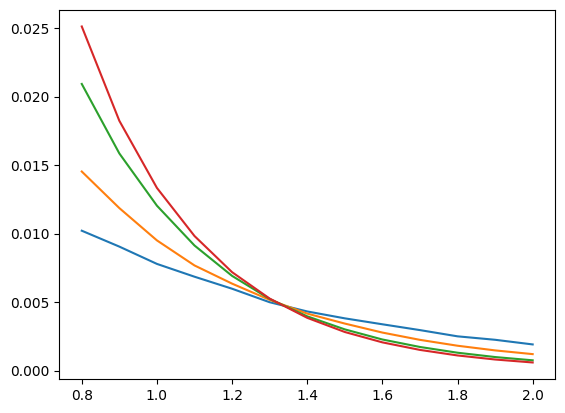

In [273]:
plt.plot(k, mu_true_shadow_1_4)
plt.plot(k, mu_true_shadow_1_6)
plt.plot(k, mu_true_shadow_1_8)
plt.plot(k, mu_true_shadow_1_10)

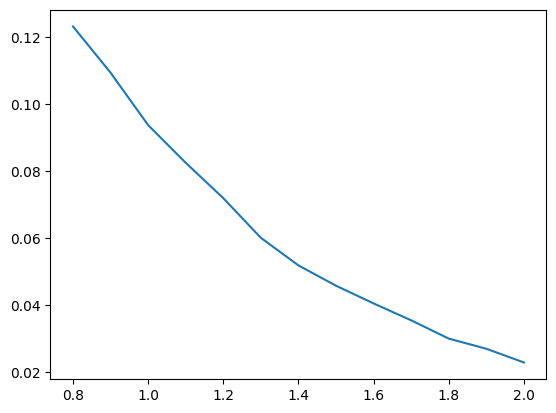

In [278]:
# plt.plot(k, yerr_true_shadow_1_4[0])
# plt.plot(k, yerr_true_shadow_1_4[1])


In [279]:
yerr_true_shadow_1_4

[array([0.12312087, 0.10932522, 0.09369105, 0.08246317, 0.07190553,
        0.06008335, 0.05185502, 0.04579953, 0.04052051, 0.03548176,
        0.03002784, 0.02699621, 0.02291127]),
 array([0.12312087, 0.10932522, 0.09369105, 0.08246317, 0.07190553,
        0.06008335, 0.05185502, 0.04579953, 0.04052051, 0.03548176,
        0.03002784, 0.02699621, 0.02291127])]

In [321]:
mu_true_shadow_1_4, yerr_true_shadow_1_4 = get_stats(get_data_to_plot_2(0, distances_4, len(k) ))
mu_true_shadow_2_4, yerr_true_shadow_2_4 = get_stats(get_data_to_plot_2(1, distances_4, len(k) ))
mu_true_surr_1_4, yerr_true_surr_1_4 = get_stats(get_data_to_plot_2(2, distances_4, len(k) ))
mu_true_surr_2_4, yerr_true_surr_2_4 = get_stats(get_data_to_plot_2(3, distances_4, len(k) ))
mu_shadow_surr_11_4, yerr_shadow_surr_11_4 = get_stats(get_data_to_plot_2(4, distances_4, len(k) ))
mu_shadow_surr_12_4, yerr_shadow_surr_12_4 = get_stats(get_data_to_plot_2(5, distances_4, len(k) ))
mu_shadow_shadow_4, yerr_shadow_shadow_4 = get_stats(get_data_to_plot_2(6, distances_4, len(k) ))
mu_surr_surr_4, yerr_surr_surr_4 = get_stats(get_data_to_plot_2(7, distances_4, len(k) ))


mu_true_shadow_1_6, yerr_true_shadow_1_6 = get_stats(get_data_to_plot_2(0, distances_6, len(k) ))
mu_true_shadow_2_6, yerr_true_shadow_2_6 = get_stats(get_data_to_plot_2(1, distances_6, len(k) ))
mu_true_surr_1_6, yerr_true_surr_1_6 = get_stats(get_data_to_plot_2(2, distances_6, len(k) ))
mu_true_surr_2_6, yerr_true_surr_2_6 = get_stats(get_data_to_plot_2(3, distances_6, len(k) ))
mu_shadow_surr_11_6, yerr_shadow_surr_11_6 = get_stats(get_data_to_plot_2(4, distances_6, len(k) ))
mu_shadow_surr_12_6, yerr_shadow_surr_12_6 = get_stats(get_data_to_plot_2(5, distances_6, len(k) ))
mu_shadow_shadow_6, yerr_shadow_shadow_6 = get_stats(get_data_to_plot_2(6, distances_6, len(k) ))
mu_surr_surr_6, yerr_surr_surr_6 = get_stats(get_data_to_plot_2(7, distances_6, len(k) ))


mu_true_shadow_1_8, yerr_true_shadow_1_8 = get_stats(get_data_to_plot_2(0, distances_8, len(k) ))
mu_true_shadow_2_8, yerr_true_shadow_2_8 = get_stats(get_data_to_plot_2(1, distances_8, len(k) ))
mu_true_surr_1_8, yerr_true_surr_1_8 = get_stats(get_data_to_plot_2(2, distances_8, len(k) ))
mu_true_surr_2_8, yerr_true_surr_2_8 = get_stats(get_data_to_plot_2(3, distances_8, len(k) ))
mu_shadow_surr_11_8, yerr_shadow_surr_11_8 = get_stats(get_data_to_plot_2(4, distances_8, len(k) ))
mu_shadow_surr_12_8, yerr_shadow_surr_12_8 = get_stats(get_data_to_plot_2(5, distances_8, len(k) ))
mu_shadow_shadow_8, yerr_shadow_shadow_8 = get_stats(get_data_to_plot_2(6, distances_8, len(k) ))
mu_surr_surr_8, yerr_surr_surr_8 = get_stats(get_data_to_plot_2(7, distances_8, len(k) ))

mu_true_shadow_1_10, yerr_true_shadow_1_10 = get_stats(get_data_to_plot_2(0, distances_10, len(k) ))
mu_true_shadow_2_10, yerr_true_shadow_2_10 = get_stats(get_data_to_plot_2(1, distances_10, len(k) ))
mu_true_surr_1_10, yerr_true_surr_1_10 = get_stats(get_data_to_plot_2(2, distances_10, len(k) ))
mu_true_surr_2_10, yerr_true_surr_2_10 = get_stats(get_data_to_plot_2(3, distances_10, len(k) ))
mu_shadow_surr_11_10, yerr_shadow_surr_11_10 = get_stats(get_data_to_plot_2(4, distances_10, len(k) ))
mu_shadow_surr_12_10, yerr_shadow_surr_12_10 = get_stats(get_data_to_plot_2(5, distances_10, len(k) ))
mu_shadow_shadow_10, yerr_shadow_shadow_10 = get_stats(get_data_to_plot_2(6, distances_10, len(k) ))
mu_surr_surr_10, yerr_surr_surr_10 = get_stats(get_data_to_plot_2(7, distances_10, len(k) ))


In [260]:
n4 = 4
data_4 = lambda idx: get_data_to_plot_scaled(idx, distances_4, len(k), n4)

mu_true_shadow_1_4, yerr_true_shadow_1_4 = get_stats(data_4(0))
mu_true_shadow_2_4, yerr_true_shadow_2_4 = get_stats(data_4(1))
mu_true_surr_1_4, yerr_true_surr_1_4     = get_stats(data_4(2))
mu_true_surr_2_4, yerr_true_surr_2_4     = get_stats(data_4(3))
mu_shadow_surr_11_4, yerr_shadow_surr_11_4 = get_stats(data_4(4))
mu_shadow_surr_12_4, yerr_shadow_surr_12_4 = get_stats(data_4(5))
mu_shadow_shadow_4, yerr_shadow_shadow_4 = get_stats(data_4(6))
mu_surr_surr_4, yerr_surr_surr_4         = get_stats(data_4(7))

# --- Process n = 6 ---
# Correction factor here is 1 / 2^3 = 0.125
n6 = 6
data_6 = lambda idx: get_data_to_plot_scaled(idx, distances_6, len(k), n6)

mu_true_shadow_1_6, yerr_true_shadow_1_6 = get_stats(data_6(0))
mu_true_shadow_2_6, yerr_true_shadow_2_6 = get_stats(data_6(1))
mu_true_surr_1_6, yerr_true_surr_1_6     = get_stats(data_6(2))
mu_true_surr_2_6, yerr_true_surr_2_6     = get_stats(data_6(3))
mu_shadow_surr_11_6, yerr_shadow_surr_11_6 = get_stats(data_6(4))
mu_shadow_surr_12_6, yerr_shadow_surr_12_6 = get_stats(data_6(5))
mu_shadow_shadow_6, yerr_shadow_shadow_6 = get_stats(data_6(6))
mu_surr_surr_6, yerr_surr_surr_6         = get_stats(data_6(7))

# --- Process n = 8 ---
# Correction factor here is 1 / 2^4 = 0.0625
n8 = 8
data_8 = lambda idx: get_data_to_plot_scaled(idx, distances_8, len(k), n8)

mu_true_shadow_1_8, yerr_true_shadow_1_8 = get_stats(data_8(0))
mu_true_shadow_2_8, yerr_true_shadow_2_8 = get_stats(data_8(1))
mu_true_surr_1_8, yerr_true_surr_1_8     = get_stats(data_8(2))
mu_true_surr_2_8, yerr_true_surr_2_8     = get_stats(data_8(3))
mu_shadow_surr_11_8, yerr_shadow_surr_11_8 = get_stats(data_8(4))
mu_shadow_surr_12_8, yerr_shadow_surr_12_8 = get_stats(data_8(5))
mu_shadow_shadow_8, yerr_shadow_shadow_8 = get_stats(data_8(6))
mu_surr_surr_8, yerr_surr_surr_8         = get_stats(data_8(7))

In [209]:
n10 = 10
data_10 = lambda idx: get_data_to_plot_scaled(idx, distances_10, len(k), n10)

mu_true_shadow_1_10, yerr_true_shadow_1_10 = get_stats(data_10(0))
mu_true_shadow_2_10, yerr_true_shadow_2_10 = get_stats(data_10(1))
mu_true_surr_1_10, yerr_true_surr_1_10     = get_stats(data_10(2))
mu_true_surr_2_10, yerr_true_surr_2_10     = get_stats(data_10(3))
mu_shadow_surr_11_10, yerr_shadow_surr_11_10 = get_stats(data_10(4))
mu_shadow_surr_12_10, yerr_shadow_surr_12_10 = get_stats(data_10(5))
mu_shadow_shadow_10, yerr_shadow_shadow_10 = get_stats(data_10(6))
mu_surr_surr_10, yerr_surr_surr_10         = get_stats(data_10(7))

In [198]:
mu_true_shadow_1_10

[0.025994837284088135,
 0.020815502714227746,
 0.016812225758891415,
 0.01366924765623278,
 0.011114650067907792,
 0.00904557989841258,
 0.0073505706722951595,
 0.005968664655530895,
 0.004840705997345073,
 0.00393597375670517,
 0.0031952588534396556,
 0.0025952316949971847,
 0.002107838060948308,
 0.001711307322451224,
 0.0013908128344660832]

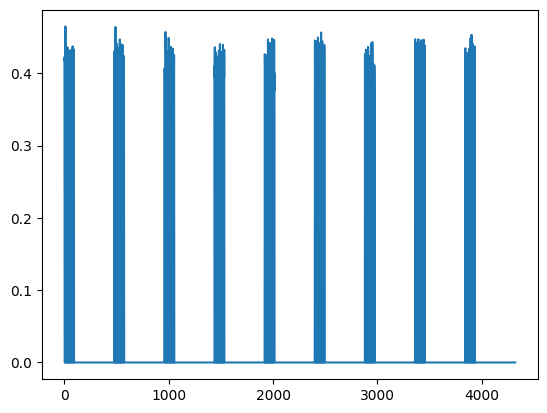

In [203]:
plt.plot(data_10(0)[0])